# Heart Disease Risk Factor Analysis — UCI Cleveland Dataset

**Research question:** *Which clinical factors are significantly associated with the
presence of heart disease?*

This is a **pure exploratory + statistical analysis**. No predictive model is trained —
every conclusion is grounded in descriptive statistics and hypothesis testing, which is
the appropriate methodology when the question is about *risk factors* rather than
*prediction*.

**Structure**
1. Dataset Description
2. Descriptive Statistics
3. Missing Values Analysis
4. Target Distribution
5. Age Analysis
6. Blood Pressure Analysis
7. Cholesterol Analysis
8. Heart Rate Analysis
9. Chest Pain & Categorical Analysis
10. Correlation Matrix
11. T-test & Chi-square Tests
12. Summary Table of Statistical Tests
13. Discussion
14. Conclusion

> Data: original UCI files (`processed.cleveland.data`), 303 patients, 13 features.
> Source: Detrano et al., Cleveland Clinic Foundation. Target `num` (0–4) is dichotomized
> to binary (0 = absence, 1 = presence of heart disease).

## Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

import os, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

%matplotlib inline
sns.set_style("whitegrid")
plt.rcParams.update({"figure.dpi": 110, "font.size": 10,
                     "axes.spines.top": False, "axes.spines.right": False})

# Consistent colours: green = no disease, red = disease
GREEN, RED, BLUE, GREY = "#27AE60", "#C0392B", "#2E75B6", "#7F8C8D"
PALETTE = {0: GREEN, 1: RED}
print("Libraries loaded.")

Libraries loaded.


## 1. Dataset Description

Loaded directly from the original UCI raw file. On Kaggle, attach the dataset containing
the 5 UCI files; the loader auto-detects the folder under `/kaggle/input/`.

In [2]:
COLS = ["age","sex","cp","trestbps","chol","fbs","restecg",
        "thalach","exang","oldpeak","slope","ca","thal","num"]

def find_data_dir():
    """Find folder containing processed_cleveland.data (Kaggle or local)."""
    for base in ("/kaggle/input", "uci_heart_data", "."):
        hits = glob.glob(os.path.join(base, "**", "processed_cleveland.data"),
                         recursive=True)
        if hits:
            return os.path.dirname(hits[0])
    raise FileNotFoundError("processed_cleveland.data not found. Attach the UCI dataset.")

DATA_DIR = find_data_dir()
df = pd.read_csv(os.path.join(DATA_DIR, "processed_cleveland.data"),
                 header=None, names=COLS, na_values="?")
for c in COLS:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# Binary target: 0 = no disease, 1 = disease present (original num 1..4)
df["target"] = (df["num"] > 0).astype(int)

print("Data directory:", DATA_DIR)
print("Shape:", df.shape, "| 13 features + target")
df.head()

Data directory: uci_heart_data
Shape: (303, 15) | 13 features + target


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0,0


**Variable dictionary**

| Variable | Description | Type | Coding / units |
|---|---|---|---|
| age | Age | Continuous | Years |
| sex | Sex | Binary | 1 = male, 0 = female |
| cp | Chest pain type | Categorical | 1 typical · 2 atypical · 3 non-anginal · 4 asymptomatic |
| trestbps | Resting blood pressure | Continuous | mm Hg |
| chol | Serum cholesterol | Continuous | mg/dl |
| fbs | Fasting blood sugar > 120 | Binary | 1 = true, 0 = false |
| restecg | Resting ECG | Categorical | 0 normal · 1 ST-T abnormality · 2 LV hypertrophy |
| thalach | Max heart rate achieved | Continuous | bpm |
| exang | Exercise-induced angina | Binary | 1 = yes, 0 = no |
| oldpeak | ST depression | Continuous | mm |
| slope | ST slope | Categorical | 1 up · 2 flat · 3 down |
| ca | Major vessels (fluoroscopy) | Ordinal | 0–3 |
| thal | Thalassemia | Categorical | 3 normal · 6 fixed · 7 reversible |
| **num → target** | **Diagnosis** | **Target** | **0 absence · 1–4 presence → binary** |

## 2. Descriptive Statistics

In [3]:
num_vars = ["age", "trestbps", "chol", "thalach", "oldpeak"]
desc = df[num_vars].describe().T[["mean","std","min","25%","50%","75%","max"]]
desc.columns = ["Mean","SD","Min","Q1","Median","Q3","Max"]
print("Continuous variables (n = {})".format(len(df)))
desc.round(2)

Continuous variables (n = 303)


,Mean,SD,Min,Q1,Median,Q3,Max
age,54.44,9.04,29.0,48.0,56.0,61.0,77.0
trestbps,131.69,17.60,94.0,120.0,130.0,140.0,200.0
chol,246.69,51.78,126.0,211.0,241.0,275.0,564.0
thalach,149.61,22.88,71.0,133.5,153.0,166.0,202.0
oldpeak,1.04,1.16,0.0,0.0,0.8,1.6,6.2


**Quick read:** the cohort skews older (mean age ≈ 54), mean cholesterol (≈ 247 mg/dl)
already exceeds the clinical 'high' threshold of 240, and mean resting BP (≈ 132 mm Hg)
sits in the elevated range — consistent with a cardiology referral population.

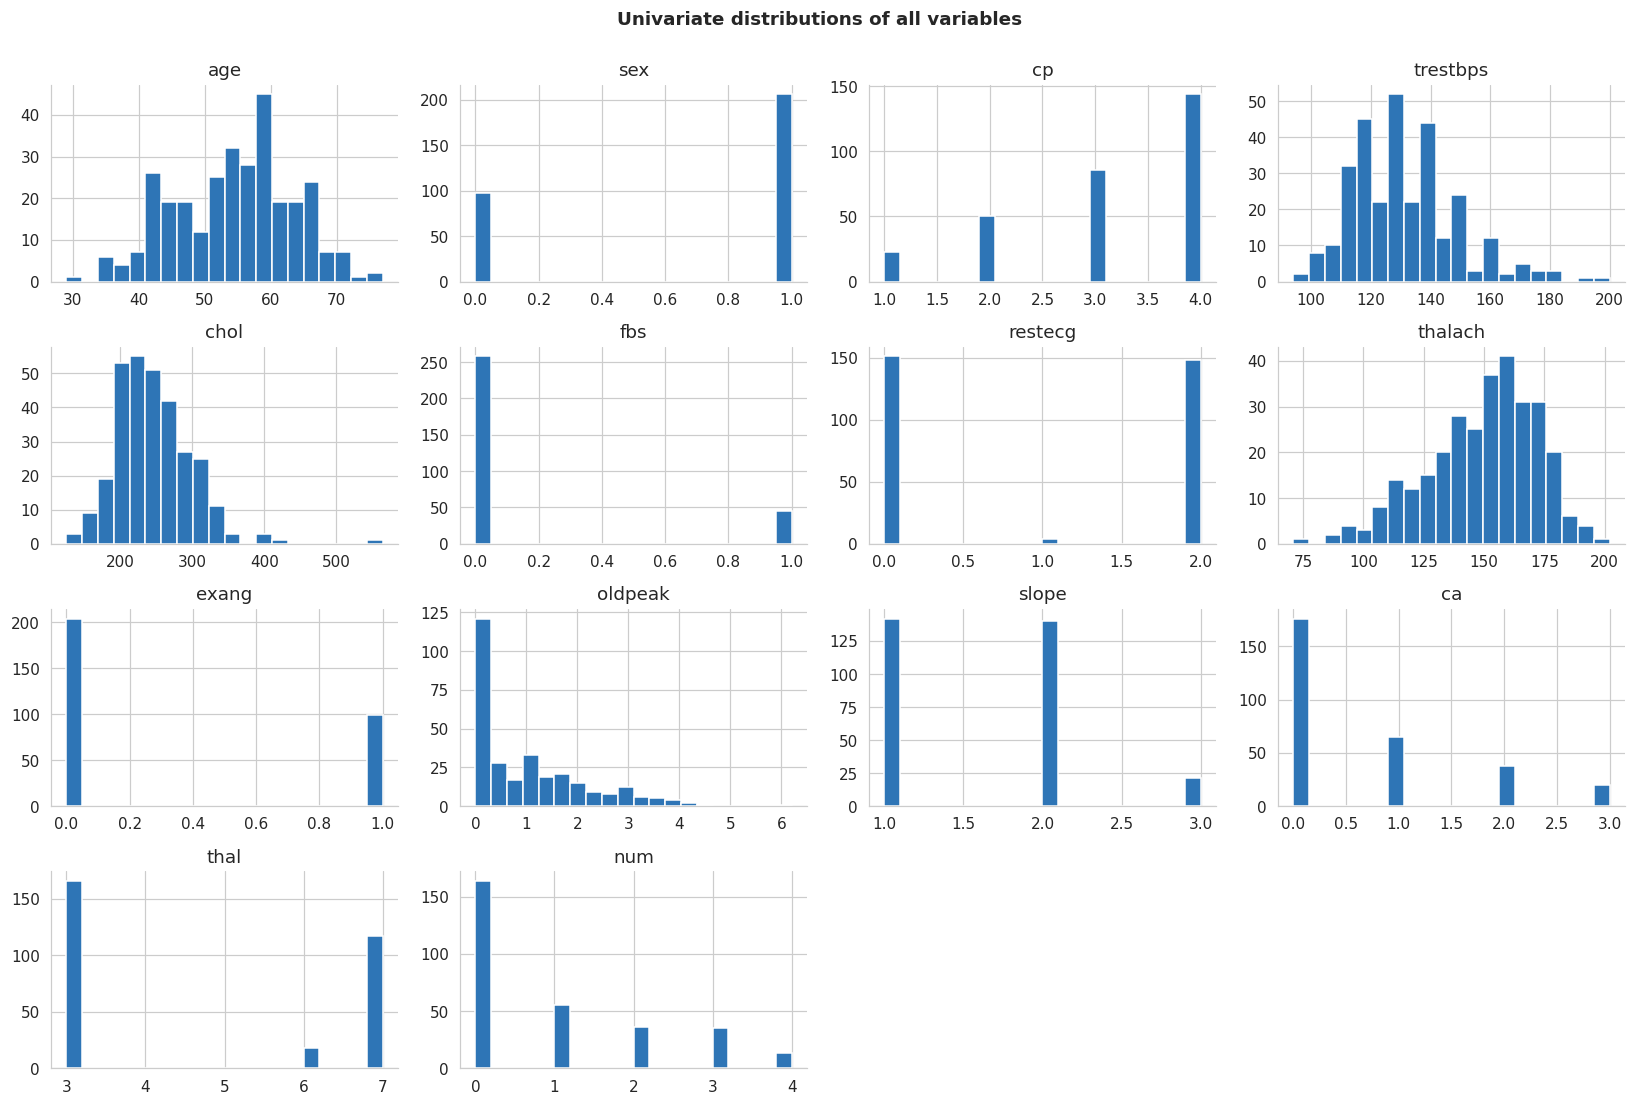

In [4]:
# Univariate overview of ALL variables at a glance
df[COLS].hist(figsize=(15, 10), bins=20, color=BLUE, edgecolor="white")
plt.suptitle("Univariate distributions of all variables", fontweight="bold", y=1.0)
plt.tight_layout(); plt.show()

## 3. Missing Values Analysis

In [5]:
miss = df[COLS].isna().sum()
miss = miss[miss > 0].sort_values(ascending=False)
total = df[COLS].shape[0] * df[COLS].shape[1]
print(f"Total missing cells: {int(miss.sum())} of {total} ({100*miss.sum()/total:.2f}%)")
pd.DataFrame({"Missing (n)": miss, "% of rows": (100*miss/len(df)).round(2)})

Total missing cells: 6 of 4242 (0.14%)


,Missing (n),% of rows
ca,4,1.32
thal,2,0.66


**Comment:** the dataset is remarkably complete — only 6 missing cells (0.14%),
confined to `ca` (4) and `thal` (2). The missing fraction is negligible, so it does not
distort any group comparison; rows are kept and missing values simply excluded
pairwise in each test.

## 4. Target Distribution

No disease (0)  : 164 (54.1%)
Disease (1)     : 139 (45.9%)


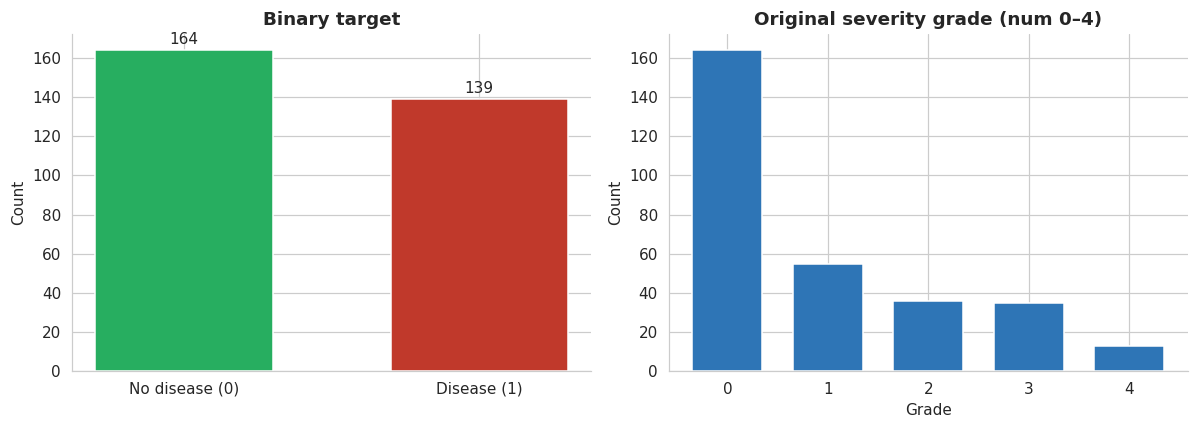

In [6]:
tcount = df["target"].value_counts().sort_index()
numcount = df["num"].value_counts().sort_index()
for k, v in tcount.items():
    print(f"{'No disease (0)' if k==0 else 'Disease (1)':<16}: {v:>3} ({100*v/len(df):.1f}%)")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
bars = ax[0].bar(["No disease (0)","Disease (1)"], tcount.values, color=[GREEN, RED], width=0.6)
ax[0].set_title("Binary target", fontweight="bold"); ax[0].set_ylabel("Count")
for r in bars: ax[0].text(r.get_x()+r.get_width()/2, r.get_height()+3, int(r.get_height()), ha="center")
ax[1].bar(numcount.index.astype(str), numcount.values, color=BLUE, width=0.7)
ax[1].set_title("Original severity grade (num 0–4)", fontweight="bold")
ax[1].set_xlabel("Grade"); ax[1].set_ylabel("Count")
plt.tight_layout(); plt.show()

**Comment:** the target is close to balanced — 164 patients (54.1%) without disease
and 139 (45.9%) with disease — so group comparisons are not distorted by class imbalance.

---
*The next four sections analyse the key continuous variables. Each pairs a distribution
plot with a box plot split by disease status, followed by a short statistical comment.*

## 5. Age Analysis

Overall: 54.4 ± 9.0 years
  No disease: 52.6 ± 9.5
  Disease   : 56.6 ± 7.9
  Welch t-test: t=-4.03, p=7.061e-05


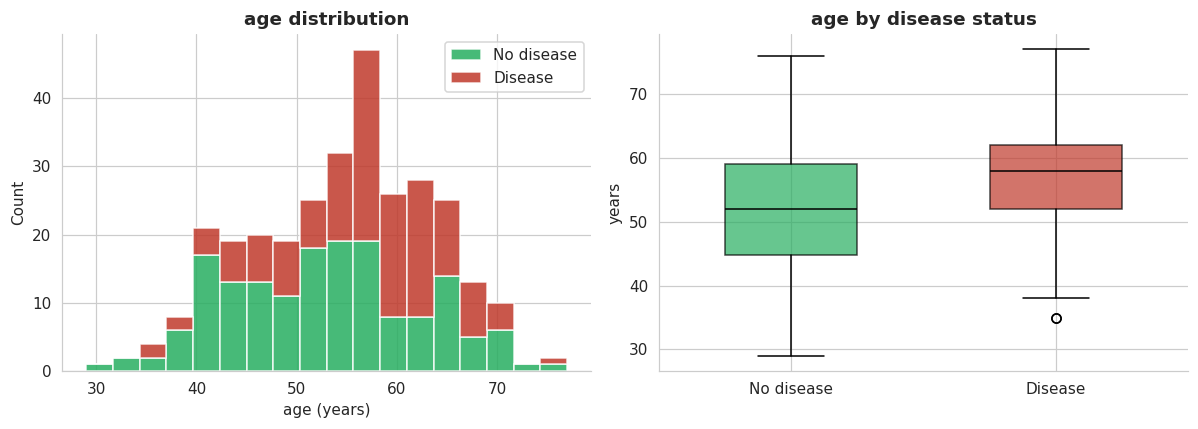

In [7]:
a = df[df.target==0]["age"].dropna()
b = df[df.target==1]["age"].dropna()
print(f"Overall: {df.age.mean():.1f} \u00b1 {df.age.std():.1f} years")
print(f"  No disease: {a.mean():.1f} \u00b1 {a.std():.1f}")
print(f"  Disease   : {b.mean():.1f} \u00b1 {b.std():.1f}")
t, p = stats.ttest_ind(a, b, equal_var=False)
print(f"  Welch t-test: t={t:.2f}, p={p:.4g}")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].hist([a, b], bins=18, color=[GREEN, RED], stacked=True, alpha=0.85, label=["No disease","Disease"])
ax[0].set_xlabel("age (years)"); ax[0].set_ylabel("Count")
ax[0].set_title("age distribution", fontweight="bold"); ax[0].legend()
bp = ax[1].boxplot([a, b], labels=["No disease","Disease"], patch_artist=True, widths=0.5)
for patch, c in zip(bp["boxes"], [GREEN, RED]): patch.set_facecolor(c); patch.set_alpha(0.7)
for m in bp["medians"]: m.set_color("black")
ax[1].set_title("age by disease status", fontweight="bold"); ax[1].set_ylabel("years")
plt.tight_layout(); plt.show()

**Comment:** patients with disease are on average ~4 years older (≈ 56.6 vs 52.6).
The difference is statistically significant (p < 0.001), confirming age as a risk factor —
though the distributions overlap, so age alone is a weak discriminator.

## 6. Blood Pressure Analysis

Overall: 131.7 ± 17.6 mm Hg
  No disease: 129.2 ± 16.2
  Disease   : 134.6 ± 18.8
  Welch t-test: t=-2.62, p=0.009409


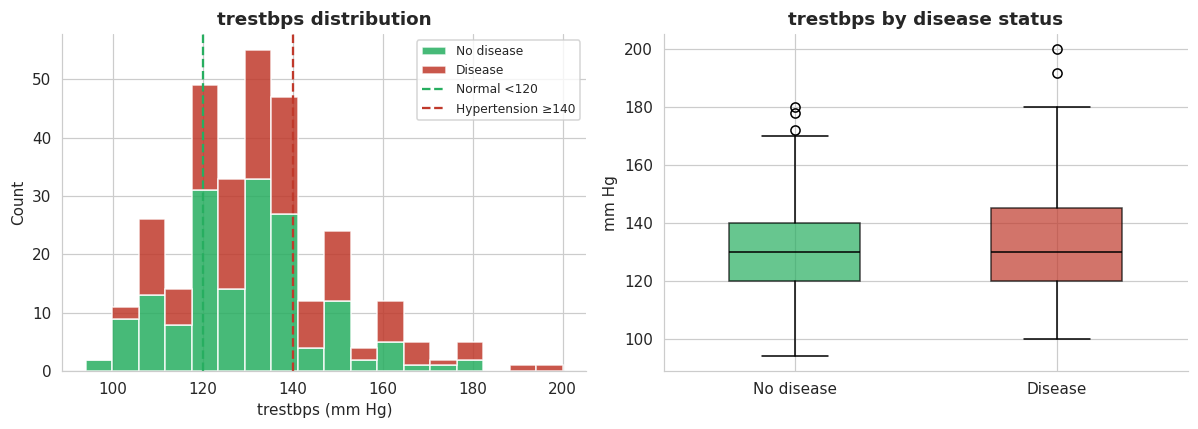

In [8]:
a = df[df.target==0]["trestbps"].dropna()
b = df[df.target==1]["trestbps"].dropna()
print(f"Overall: {df.trestbps.mean():.1f} \u00b1 {df.trestbps.std():.1f} mm Hg")
print(f"  No disease: {a.mean():.1f} \u00b1 {a.std():.1f}")
print(f"  Disease   : {b.mean():.1f} \u00b1 {b.std():.1f}")
t, p = stats.ttest_ind(a, b, equal_var=False)
print(f"  Welch t-test: t={t:.2f}, p={p:.4g}")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].hist([a, b], bins=18, color=[GREEN, RED], stacked=True, alpha=0.85, label=["No disease","Disease"])
ax[0].set_xlabel("trestbps (mm Hg)"); ax[0].set_ylabel("Count")
ax[0].set_title("trestbps distribution", fontweight="bold"); ax[0].legend()
ax[0].axvline(120, color=GREEN, ls="--", lw=1.5, label="Normal <120")
ax[0].axvline(140, color=RED, ls="--", lw=1.5, label="Hypertension \u2265140")
ax[0].legend(fontsize=8)
bp = ax[1].boxplot([a, b], labels=["No disease","Disease"], patch_artist=True, widths=0.5)
for patch, c in zip(bp["boxes"], [GREEN, RED]): patch.set_facecolor(c); patch.set_alpha(0.7)
for m in bp["medians"]: m.set_color("black")
ax[1].set_title("trestbps by disease status", fontweight="bold"); ax[1].set_ylabel("mm Hg")
plt.tight_layout(); plt.show()

**Comment:** resting BP is modestly higher in the disease group (≈ 134.6 vs 129.2 mm Hg),
significant (p ≈ 0.009) but small in magnitude — a weak risk factor.

## 7. Cholesterol Analysis

Overall: 246.7 ± 51.8 mg/dl
  No disease: 242.6 ± 53.5
  Disease   : 251.5 ± 49.5
  Welch t-test: t=-1.49, p=0.1366


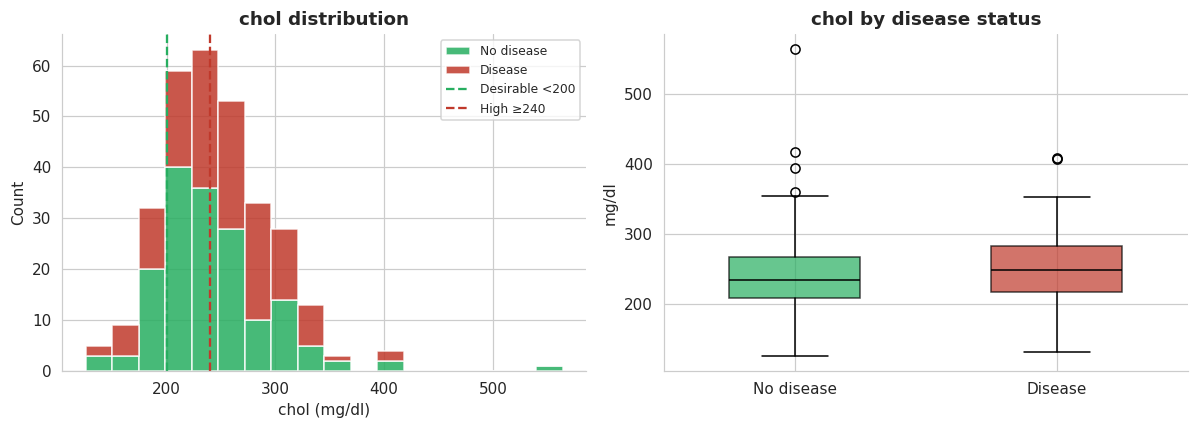

In [9]:
a = df[df.target==0]["chol"].dropna()
b = df[df.target==1]["chol"].dropna()
print(f"Overall: {df.chol.mean():.1f} \u00b1 {df.chol.std():.1f} mg/dl")
print(f"  No disease: {a.mean():.1f} \u00b1 {a.std():.1f}")
print(f"  Disease   : {b.mean():.1f} \u00b1 {b.std():.1f}")
t, p = stats.ttest_ind(a, b, equal_var=False)
print(f"  Welch t-test: t={t:.2f}, p={p:.4g}")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].hist([a, b], bins=18, color=[GREEN, RED], stacked=True, alpha=0.85, label=["No disease","Disease"])
ax[0].set_xlabel("chol (mg/dl)"); ax[0].set_ylabel("Count")
ax[0].set_title("chol distribution", fontweight="bold"); ax[0].legend()
ax[0].axvline(200, color=GREEN, ls="--", lw=1.5, label="Desirable <200")
ax[0].axvline(240, color=RED, ls="--", lw=1.5, label="High \u2265240")
ax[0].legend(fontsize=8)
bp = ax[1].boxplot([a, b], labels=["No disease","Disease"], patch_artist=True, widths=0.5)
for patch, c in zip(bp["boxes"], [GREEN, RED]): patch.set_facecolor(c); patch.set_alpha(0.7)
for m in bp["medians"]: m.set_color("black")
ax[1].set_title("chol by disease status", fontweight="bold"); ax[1].set_ylabel("mg/dl")
plt.tight_layout(); plt.show()

**Comment:** surprisingly, cholesterol does **not** differ significantly between groups
(p ≈ 0.14). In a population already referred for cardiac evaluation, total cholesterol is a
poor discriminator — a counter-intuitive but well-documented finding for this cohort. Note
the extreme right-tail outlier near 564 mg/dl.

## 8. Heart Rate Analysis

Overall: 149.6 ± 22.9 bpm
  No disease: 158.4 ± 19.2
  Disease   : 139.3 ± 22.6
  Welch t-test: t=7.86, p=9.106e-14


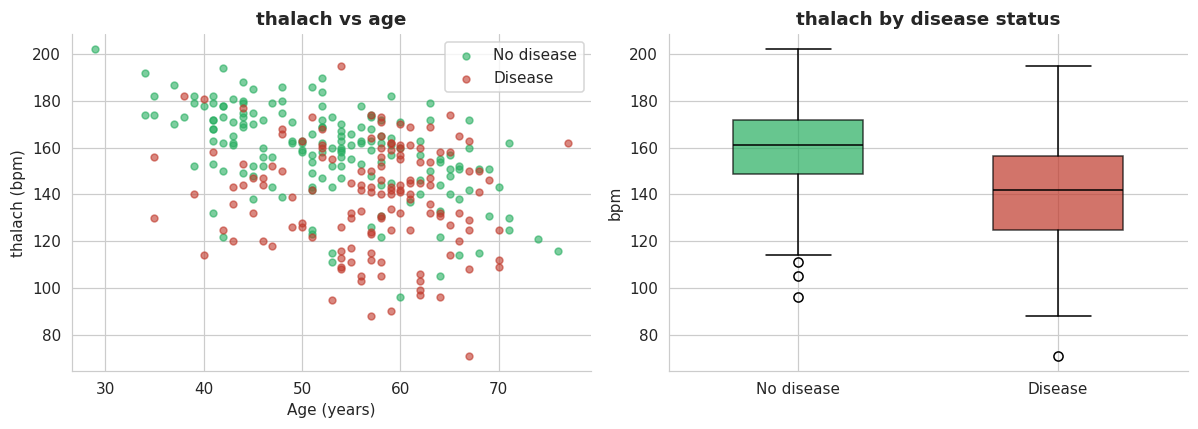

In [10]:
a = df[df.target==0]["thalach"].dropna()
b = df[df.target==1]["thalach"].dropna()
print(f"Overall: {df.thalach.mean():.1f} \u00b1 {df.thalach.std():.1f} bpm")
print(f"  No disease: {a.mean():.1f} \u00b1 {a.std():.1f}")
print(f"  Disease   : {b.mean():.1f} \u00b1 {b.std():.1f}")
t, p = stats.ttest_ind(a, b, equal_var=False)
print(f"  Welch t-test: t={t:.2f}, p={p:.4g}")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].scatter(df[df.target==0].age, a, color=GREEN, alpha=0.6, s=20, label="No disease")
ax[0].scatter(df[df.target==1].age, b, color=RED, alpha=0.6, s=20, label="Disease")
ax[0].set_xlabel("Age (years)"); ax[0].set_ylabel("thalach (bpm)")
ax[0].set_title("thalach vs age", fontweight="bold"); ax[0].legend()
bp = ax[1].boxplot([a, b], labels=["No disease","Disease"], patch_artist=True, widths=0.5)
for patch, c in zip(bp["boxes"], [GREEN, RED]): patch.set_facecolor(c); patch.set_alpha(0.7)
for m in bp["medians"]: m.set_color("black")
ax[1].set_title("thalach by disease status", fontweight="bold"); ax[1].set_ylabel("bpm")
plt.tight_layout(); plt.show()

**Comment:** maximum heart rate is the strongest continuous factor. Disease patients
reach a substantially **lower** peak (≈ 139 vs 158 bpm), highly significant (p < 0.001) and
negatively associated with disease. The scatter shows the expected decline of peak heart
rate with age, with disease cases clustering lower across all ages.

## 9. Chest Pain & Categorical Analysis

The strongest signals in this dataset are categorical. Below, each categorical variable is
plotted as a count split by disease status (`hue=target`), revealing how disease prevalence
shifts across categories.

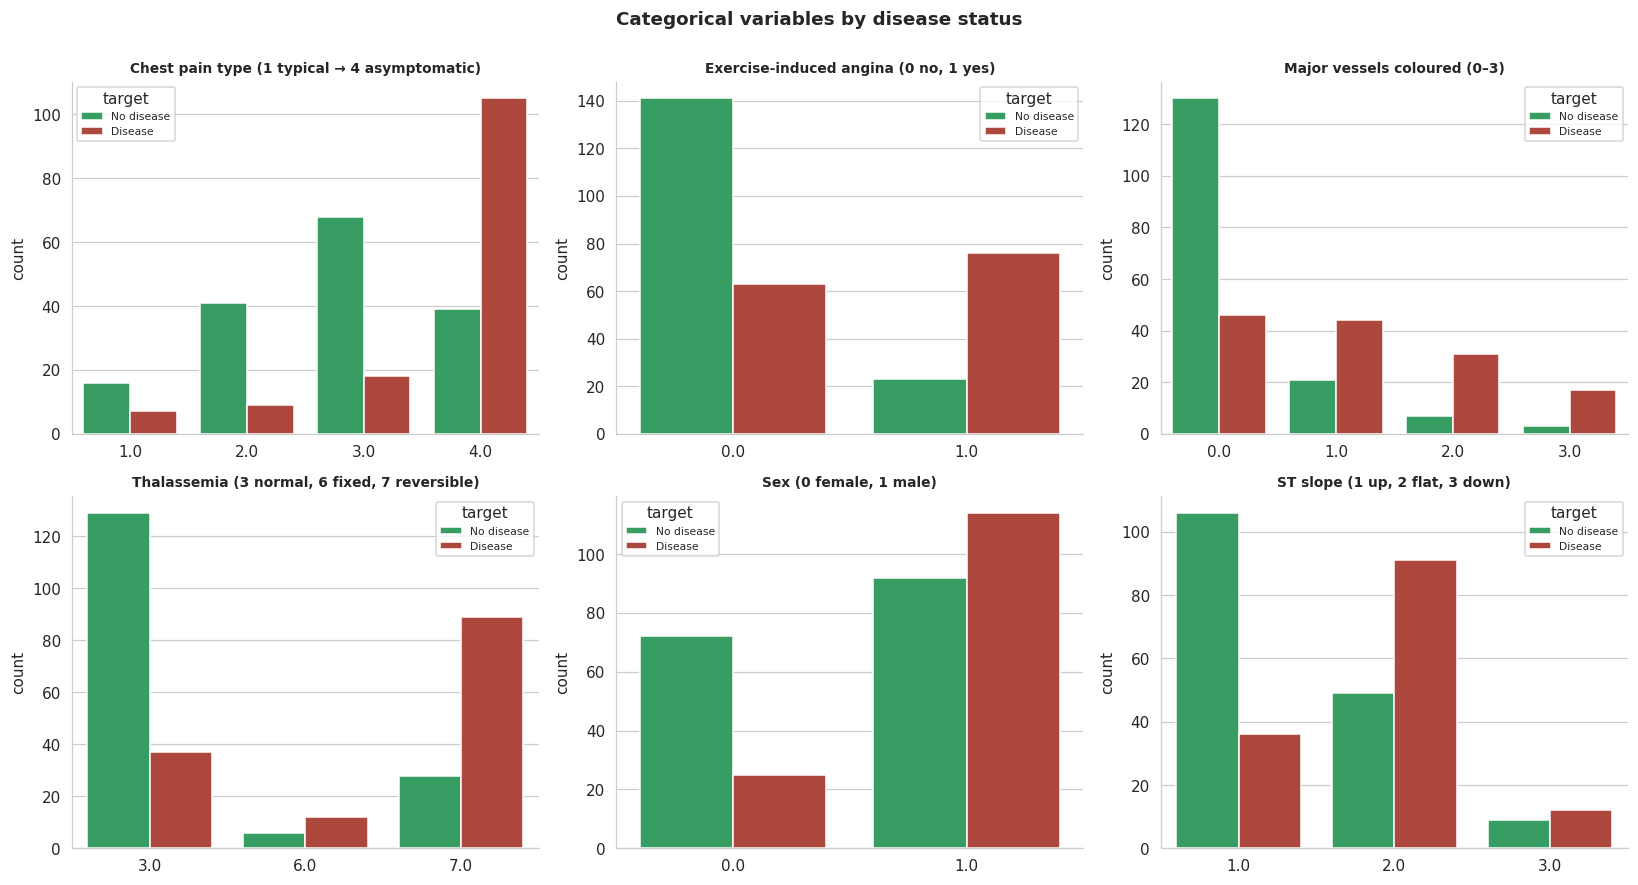

In [11]:
cat_vars = ["cp", "exang", "ca", "thal", "sex", "slope"]
cat_titles = {
    "cp":"Chest pain type (1 typical → 4 asymptomatic)",
    "exang":"Exercise-induced angina (0 no, 1 yes)",
    "ca":"Major vessels coloured (0–3)",
    "thal":"Thalassemia (3 normal, 6 fixed, 7 reversible)",
    "sex":"Sex (0 female, 1 male)",
    "slope":"ST slope (1 up, 2 flat, 3 down)",
}
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, v in zip(axes.ravel(), cat_vars):
    sns.countplot(data=df, x=v, hue="target", palette=PALETTE, ax=ax)
    ax.set_title(cat_titles[v], fontsize=9, fontweight="bold")
    ax.set_xlabel(""); ax.legend(title="target", labels=["No disease","Disease"], fontsize=7)
plt.suptitle("Categorical variables by disease status", fontweight="bold", y=1.0)
plt.tight_layout(); plt.show()

In [12]:
# Disease rate within each category — makes the association explicit
for v in ["cp", "exang", "ca", "thal"]:
    rate = df.groupby(v)["target"].mean().mul(100).round(1)
    print(f"\nDisease rate (%) by {v}:")
    for k, val in rate.items():
        print(f"   {v}={k!s:<4}: {val:>5.1f}%")


Disease rate (%) by cp:
   cp=1.0 :  30.4%
   cp=2.0 :  18.0%
   cp=3.0 :  20.9%
   cp=4.0 :  72.9%

Disease rate (%) by exang:
   exang=0.0 :  30.9%
   exang=1.0 :  76.8%

Disease rate (%) by ca:
   ca=0.0 :  26.1%
   ca=1.0 :  67.7%
   ca=2.0 :  81.6%
   ca=3.0 :  85.0%

Disease rate (%) by thal:
   thal=3.0 :  22.3%
   thal=6.0 :  66.7%
   thal=7.0 :  76.1%


**Comment:**
- **`cp` (chest pain):** asymptomatic patients (type 4) have by far the highest disease
  rate — counter-intuitively, those *without* typical chest pain are most likely to have
  disease.
- **`exang` (exercise angina):** disease rate jumps sharply when angina is provoked by
  exercise (1 vs 0).
- **`ca` (vessels):** disease rate rises monotonically with the number of vessels coloured
  by fluoroscopy — a clear dose-response pattern.
- **`thal`:** the reversible-defect group (7) is strongly enriched for disease.

These categorical factors carry the strongest associations, which the formal tests in
Section 11 confirm.

## 10. Correlation Matrix

Because several variables are categorical/ordinal encodings, we report **both** Pearson
(linear) and Spearman (rank-based, robust to non-linear monotonic relationships)
correlations. Spearman is generally more appropriate for the ordinal variables here.

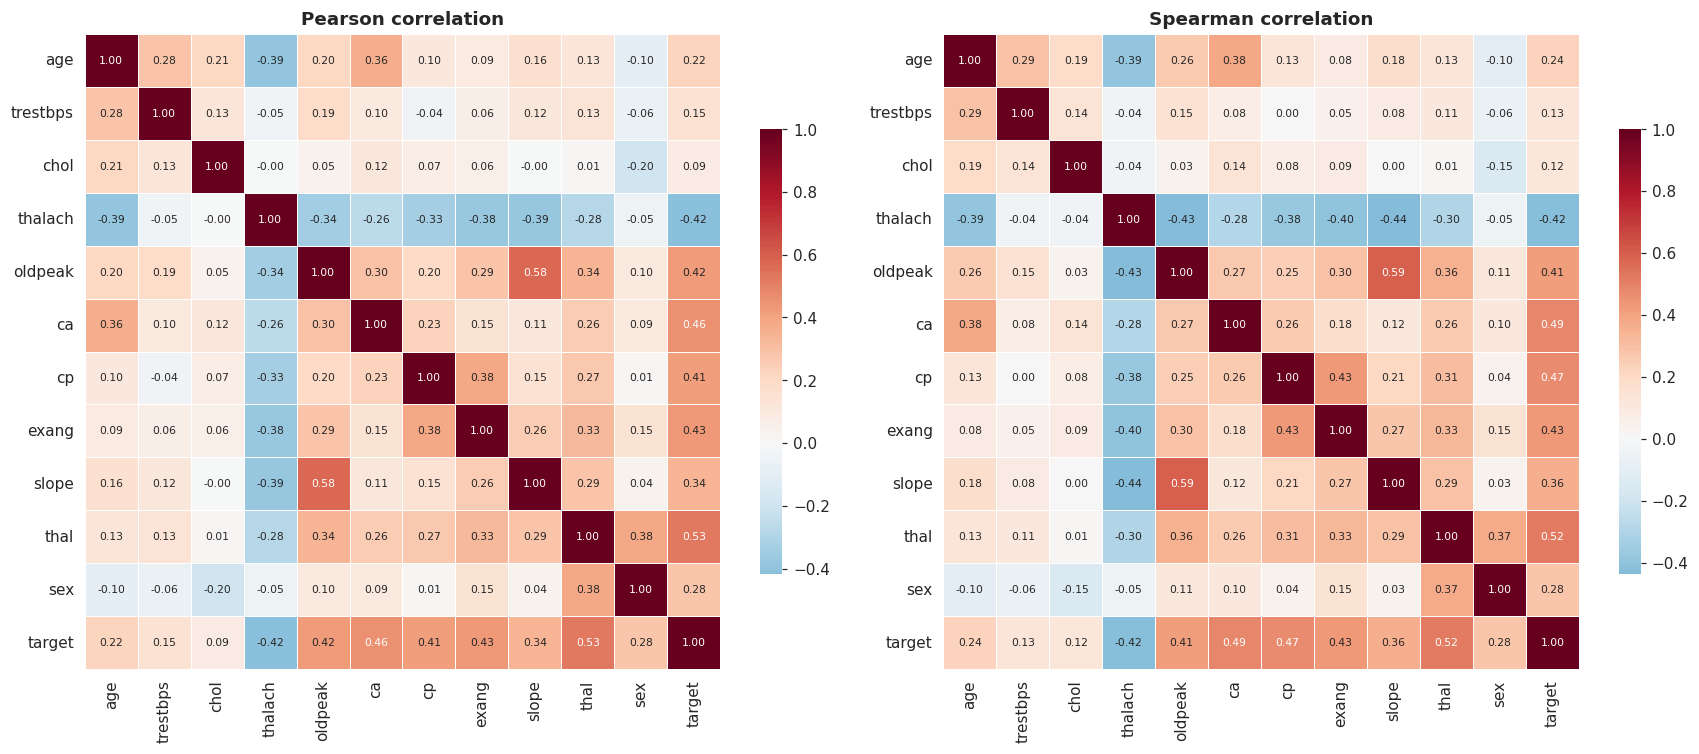

In [13]:
corr_vars = ["age","trestbps","chol","thalach","oldpeak","ca","cp",
             "exang","slope","thal","sex","target"]
fig, ax = plt.subplots(1, 2, figsize=(16, 6.5))
for a, method in zip(ax, ["pearson", "spearman"]):
    cm = df[corr_vars].corr(method=method)
    sns.heatmap(cm, annot=True, fmt=".2f", cmap="RdBu_r", center=0, square=True,
                cbar_kws={"shrink":0.7}, annot_kws={"size":7}, linewidths=0.5, ax=a)
    a.set_title(f"{method.capitalize()} correlation", fontweight="bold")
plt.tight_layout(); plt.show()

In [14]:
# Ranked association of each feature with the target (both methods)
p = df[corr_vars].corr("pearson")["target"].drop("target")
s = df[corr_vars].corr("spearman")["target"].drop("target")
tbl = pd.DataFrame({"Pearson": p.round(3), "Spearman": s.round(3)})
tbl["abs_spearman"] = tbl["Spearman"].abs()
tbl.sort_values("abs_spearman", ascending=False).drop(columns="abs_spearman")

,Pearson,Spearman
thal,0.526,0.522
ca,0.460,0.489
cp,0.414,0.472
exang,0.432,0.432
thalach,-0.417,-0.423
oldpeak,0.425,0.413
slope,0.339,0.364
sex,0.277,0.277
age,0.223,0.237
trestbps,0.151,0.128


**Comment:** by either method, the strongest correlates of disease are `thal`, `ca`,
`exang`, `oldpeak`, `cp` and `thalach` (negative). `chol` is the weakest (≈ 0.08),
reinforcing the Section 7 finding. Spearman values are slightly higher for the ordinal
variables, as expected.

## 11. T-test & Chi-square Tests

This is the core of the analysis: every conclusion about a "risk factor" is backed by a
formal hypothesis test, not just a chart.

- **Welch's t-test** — continuous variables, comparing the mean of the disease vs no-disease group.
- **Chi-square test of independence** — categorical variables vs the target.

Significance codes: `*** p<0.001 · ** p<0.01 · * p<0.05 · ns`.

In [15]:
def sig_code(p):
    return "***" if p<0.001 else "**" if p<0.01 else "*" if p<0.05 else "ns"

rows = []
for v in ["age","trestbps","chol","thalach","oldpeak"]:
    a = df[df.target==0][v].dropna(); b = df[df.target==1][v].dropna()
    t, p = stats.ttest_ind(a, b, equal_var=False)
    rows.append([v, "Welch t-test", f"{a.mean():.1f} / {b.mean():.1f}", round(t,2), p, sig_code(p)])
for v in ["sex","cp","fbs","restecg","exang","slope","ca","thal"]:
    chi2, p, dof, _ = stats.chi2_contingency(pd.crosstab(df[v], df.target))
    rows.append([v, "Chi-square", "—", round(chi2,2), p, sig_code(p)])

res = pd.DataFrame(rows, columns=["Feature","Test","Mean no/yes","Statistic","p_raw","Sig."])
res["p-value"] = res["p_raw"].apply(lambda p: "<0.001" if p<0.001 else f"{p:.3f}")
res[["Feature","Test","Mean no/yes","Statistic","p-value","Sig."]]

,Feature,Test,Mean no/yes,Statistic,p-value,Sig.
0,age,Welch t-test,52.6 / 56.6,-4.03,<0.001,***
1,trestbps,Welch t-test,129.2 / 134.6,-2.62,0.009,**
2,chol,Welch t-test,242.6 / 251.5,-1.49,0.137,ns
3,thalach,Welch t-test,158.4 / 139.3,7.86,<0.001,***
4,oldpeak,Welch t-test,0.6 / 1.6,-7.82,<0.001,***
5,sex,Chi-square,—,22.04,<0.001,***
6,cp,Chi-square,—,81.82,<0.001,***
7,fbs,Chi-square,—,0.08,0.781,ns
8,restecg,Chi-square,—,10.05,0.007,**
9,exang,Chi-square,—,54.69,<0.001,***


**Comment:** 11 of 13 features are significantly associated with disease. The only two
**non-significant** factors are `chol` (cholesterol, p ≈ 0.14) and `fbs` (fasting blood
sugar, p ≈ 0.78) — a notable result, since both are popularly assumed to be major cardiac
risk markers. The strongest associations are the categorical/exercise variables
(`thal`, `cp`, `ca`, `exang`, `slope`) and the continuous `thalach` and `oldpeak`.

## 12. Summary Table of Statistical Tests

A single consolidated table of every test performed — ready to paste directly into a
report. Variables are ordered by ascending p-value (strongest associations first), with a
clear Yes/No significance flag at α = 0.05.

In [16]:
# Build a report-ready summary table from the test results computed in Section 11
summary = res[["Feature", "Test", "p_raw"]].copy()
summary["p-value"] = summary["p_raw"].apply(lambda p: "<0.001" if p < 0.001 else f"{p:.3f}")
summary["Significant (α=0.05)"] = np.where(summary["p_raw"] < 0.05, "Yes", "No")
summary["Significant (Bonferroni)"] = np.where(summary["p_raw"] < 0.05/len(summary), "Yes", "No")

# friendly variable labels
labels = {
    "age":"Age", "trestbps":"Resting BP", "chol":"Cholesterol", "thalach":"Max heart rate",
    "oldpeak":"ST depression", "sex":"Sex", "cp":"Chest pain type", "fbs":"Fasting blood sugar",
    "restecg":"Resting ECG", "exang":"Exercise angina", "slope":"ST slope",
    "ca":"Vessels (fluoroscopy)", "thal":"Thalassemia",
}
summary["Variable"] = summary["Feature"].map(labels)

summary = summary.sort_values("p_raw").reset_index(drop=True)
summary_out = summary[["Variable", "Test", "p-value",
                       "Significant (α=0.05)", "Significant (Bonferroni)"]]

n_sig = (summary["p_raw"] < 0.05).sum()
print(f"{n_sig} of {len(summary)} variables significantly associated with heart disease "
      f"(α = 0.05).\n")
summary_out

11 of 13 variables significantly associated with heart disease (α = 0.05).



,Variable,Test,p-value,Significant (α=0.05),Significant (Bonferroni)
0,Thalassemia,Chi-square,<0.001,Yes,Yes
1,Chest pain type,Chi-square,<0.001,Yes,Yes
2,Vessels (fluoroscopy),Chi-square,<0.001,Yes,Yes
3,Max heart rate,Welch t-test,<0.001,Yes,Yes
4,Exercise angina,Chi-square,<0.001,Yes,Yes
5,ST depression,Welch t-test,<0.001,Yes,Yes
6,ST slope,Chi-square,<0.001,Yes,Yes
7,Sex,Chi-square,<0.001,Yes,Yes
8,Age,Welch t-test,<0.001,Yes,Yes
9,Resting ECG,Chi-square,0.007,Yes,No


**How to read this table.** Variables with *Yes* are significantly associated with the
presence of heart disease. The extra **Bonferroni** column applies the stricter multiple-
comparison threshold (α ≈ 0.05 / 13 ≈ 0.004); the strong factors survive it, while only the
most borderline results (e.g. resting ECG) may drop out — useful to mention for rigour.
The two **non-significant** factors are cholesterol and fasting blood sugar.

## 13. Discussion

Bringing the descriptive, correlational and inferential results together:

- **Exercise-stress and angiographic factors dominate.** `thal`, `ca`, `exang`, `oldpeak`,
  `thalach` and `cp` show the strongest associations across correlation *and* formal
  testing — they reflect the heart's response under stress and direct anatomical evidence
  of vessel disease.
- **Maximum heart rate (`thalach`) is the most informative continuous factor:** disease
  patients reach a peak ~19 bpm lower (p < 0.001), a strong *negative* association.
- **Cholesterol and fasting blood sugar are not significant.** Both popular markers fail to
  distinguish the groups in this referral cohort — a key, somewhat counter-intuitive,
  finding that depends on having run the tests rather than eyeballing charts.
- **Demographics matter modestly.** Older age and male sex are both significant but with
  smaller effects than the stress-test variables.

**Methodological note.** This study deliberately stops at analysis and inference. Because
the research question concerns *which factors are associated with disease* (not building a
predictor), descriptive statistics plus hypothesis testing is the methodologically correct
approach; training a classifier would answer a different question and would not add
evidence about risk factors.

**Limitations.** Single-site referral cohort (Cleveland Clinic), small sample (n = 303),
male-skewed (68%). All findings are associational, not causal. Multiple comparisons were
made; with 13 tests, a Bonferroni-style adjustment (α ≈ 0.05/13 ≈ 0.004) would still leave
the strong factors significant but should be noted for borderline cases such as `restecg`.

## 14. Conclusion

Among the 13 clinical variables examined in the UCI Cleveland heart-disease dataset, the
factors most significantly associated with the presence of heart disease are **thalassemia
status (`thal`), number of vessels coloured by fluoroscopy (`ca`), chest-pain type (`cp`),
exercise-induced angina (`exang`), ST depression (`oldpeak`)** and **maximum heart rate
(`thalach`, inversely)**. Age, sex and resting blood pressure contribute smaller but still
significant effects.

In contrast, **serum cholesterol and fasting blood sugar were not significantly different**
between patients with and without heart disease in this cohort. Overall, indicators of the
heart's response to exercise stress and direct angiographic evidence are far more
informative risk factors than the commonly cited cholesterol level.